In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Import data
CSV_FILE = 'datasets/snd_try_100_50_2.csv'
# CSV_FILE = 'datasets/add_lowpass_filter.csv'
df = pd.read_csv(CSV_FILE).drop('Unnamed: 0', axis=1)
mapping = {'clear': 0, 'drive': 1, 'drop': 2, 'lob': 3, 'smash': 4}
df['skill_type'] = df['skill_type'].map(mapping)
df.head()

,skill_type,user,sample_number,time,X_Accelerometer,Y_Accelerometer,Z_Accelerometer,X_Linear Accelerometer,Y_Linear Accelerometer,Z_Linear Accelerometer,...,Y_Gyroscope_mean,Y_Gyroscope_std,Z_Gyroscope_mean,Z_Gyroscope_std,X_Magnetometer_mean,X_Magnetometer_std,Y_Magnetometer_mean,Y_Magnetometer_std,Z_Magnetometer_mean,Z_Magnetometer_std
0,0,alan,0,1.0,9.338780,-3.936215,-6.037695,0.567103,-4.267427,-1.657731,...,-0.213414,1.337155,-0.379343,0.895364,53.719638,0.480646,-7.309696,5.413812,2.647434,4.161715
1,0,alan,0,1.5,0.870141,11.799064,-4.454138,-0.328516,2.950434,-0.391986,...,-0.828747,1.027613,-1.145006,0.794134,46.755561,9.129871,13.328287,21.591403,-3.055479,4.586475
2,0,alan,0,2.0,43.521097,-40.772214,-6.684350,39.736199,-46.373154,0.424808,...,0.308135,2.647437,-0.062310,3.964062,20.686822,23.003404,37.519637,10.533328,5.648036,18.572012
3,0,alan,0,2.5,2.193688,-7.904163,-2.930905,-5.556938,-2.623423,-0.053811,...,0.345735,2.795010,-0.043107,4.395283,14.531400,17.360566,15.424609,30.936991,-9.743632,31.472950
4,0,alan,0,3.0,3.929479,-5.654791,-2.183060,-2.471837,0.541462,1.335886,...,-0.113161,2.079481,-0.099830,2.379393,28.921728,4.072667,-15.514430,14.959793,-37.601118,4.054646


In [180]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

X = df.drop(columns="skill_type user sample_number time".split()).copy()
t = df['skill_type']

# X_train, X_test, y_train, y_test = train_test_split(X, t, test_size = 0.25, random_state = 32)

X_train = df[(df["user"] != "keeley")].drop(columns="skill_type user sample_number time".split()).copy()
X_test = df[(df["user"] == "keeley")].drop(columns="skill_type user sample_number time".split()).copy()
y_train = df[(df["user"] != "keeley")]['skill_type']
y_test = df[(df["user"] == "keeley") ]['skill_type']


# rf = RandomForestClassifier(n_estimators = 100, random_state = 32)
#
# param_grid = {
#     'n_estimators': [200, 300, 500],
#     'max_features': ['auto', 'sqrt', 'log2'],
#     'max_depth' : [4,5,6,7,8],
#     'criterion' :['gini', 'entropy']
# }
#
# CV_rfc = GridSearchCV(estimator=rf, param_grid=param_grid, cv= 5)
# CV_rfc.fit(X_train, y_train)
# CV_rfc.best_params_

# rfc=RandomForestClassifier(random_state=32, max_features='sqrt',
#                            n_estimators= 500, max_depth=6, criterion='entropy')
# rfc.fit(X_train, y_train)
# y_pred=rfc.predict(X_test)
# confusion_hard = confusion_matrix(y_test, y_pred)
# accuracy = accuracy_score(y_test, y_pred)
# print(classification_report(y_test, y_pred))

rfc_base=RandomForestClassifier(random_state=42)
rfc_base.fit(X_train, y_train)

y_pred=rfc_base.predict(X_test)
print(classification_report(y_test, y_pred))
# y_train_pred = rfc_base.predict(X_train)
# print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.49      0.23      0.31        78
           1       0.49      0.90      0.63        77
           2       0.22      0.31      0.26        70
           3       0.30      0.27      0.28        78
           4       0.35      0.15      0.21        78

    accuracy                           0.37       381
   macro avg       0.37      0.37      0.34       381
weighted avg       0.37      0.37      0.34       381



In [175]:

y_pred = np.random.random_integers(0, 4, size=len(y_test))
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.23      0.23      0.23        56
           1       0.24      0.23      0.23        56
           2       0.23      0.25      0.24        56
           3       0.16      0.15      0.15        53
           4       0.21      0.20      0.20        56

    accuracy                           0.21       277
   macro avg       0.21      0.21      0.21       277
weighted avg       0.21      0.21      0.21       277



/var/folders/ck/63g66f6935lgl8mlzt8bpztr0000gn/T/ipykernel_1491/3454072033.py:1: DeprecationWarning: This function is deprecated. Please call randint(0, 4 + 1) instead
  y_pred = np.random.random_integers(0, 4, size=len(y_test))


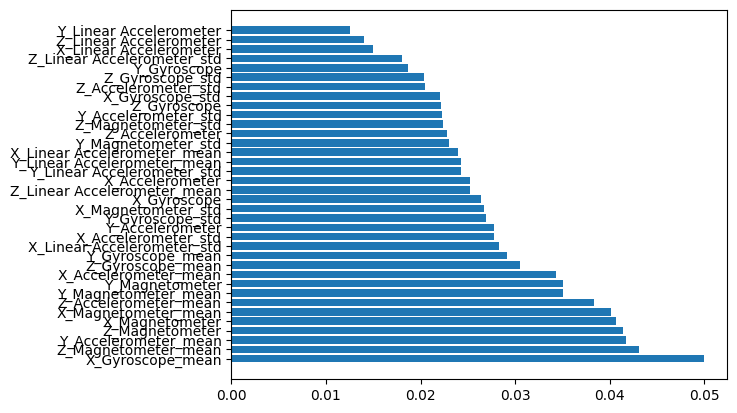

In [129]:
#Feature importance
feature_importance = pd.DataFrame(rfc_base.feature_importances_,
                                   index = X_train.columns,
                                   columns=['importance']).sort_values('importance',ascending=False)

fig = plt.figure()
plt.barh(feature_importance.index, feature_importance.importance)
# If you want to define your own labels,
# change indices to a list of labels on the following line.
#plt.yticks(range(X.shape[1]), indices)
#plt.ylim([-1, X.shape[1]])
plt.show()

In [169]:
CSV_FILE = 'datasets/applied_kalman_100_50_2.csv'
# CSV_FILE = 'datasets/add_lowpass_filter.csv'
df = pd.read_csv(CSV_FILE).drop('Unnamed: 0', axis=1)

mapping = {'clear': 0, 'drive': 1, 'drop': 2, 'lob': 3, 'smash': 4}
df['skill_type'] = df['skill_type'].map(mapping)
df.head()

,skill_type,user,sample_number,time,X_Accelerometer,Y_Accelerometer,Z_Accelerometer,X_Linear Accelerometer,Y_Linear Accelerometer,Z_Linear Accelerometer,...,Y_Gyroscope_mean,Y_Gyroscope_std,Z_Gyroscope_mean,Z_Gyroscope_std,X_Magnetometer_mean,X_Magnetometer_std,Y_Magnetometer_mean,Y_Magnetometer_std,Z_Magnetometer_mean,Z_Magnetometer_std
0,0,alan,0,1.0,10.015736,-3.462636,-6.933210,1.206285,-3.037109,-2.727016,...,-0.177359,1.013054,-0.316081,0.814824,53.716032,0.406747,-7.737982,4.491203,2.922625,3.804989
1,0,alan,0,1.5,1.782131,10.287960,-3.968027,0.119563,1.682134,0.385971,...,-0.787543,0.947526,-1.102086,0.807818,47.474294,8.480605,11.822258,21.137475,-2.933767,4.459675
2,0,alan,0,2.0,28.046992,-40.121204,-10.520098,27.173934,-47.147632,-5.238086,...,0.134429,2.437147,-0.413544,3.329650,21.933205,23.034884,36.491487,10.751618,5.768293,17.641286
3,0,alan,0,2.5,2.117197,-9.026405,-3.545560,-5.329449,-3.340135,-0.715061,...,0.320222,2.542246,-0.017540,4.084905,14.510814,16.457552,17.340534,30.019623,-8.955347,30.507657
4,0,alan,0,3.0,4.520707,-6.694772,-1.277303,-2.035962,-0.631494,1.997275,...,-0.065378,1.868067,0.133272,2.740709,28.063554,3.874450,-13.830331,17.545806,-36.954149,5.484286


In [177]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

X = df.drop(columns="skill_type user sample_number time".split()).copy()
t = df['skill_type']

# X_train, X_test, y_train, y_test = train_test_split(X, t, test_size = 0.25, random_state = 32)

X_train = df[(df["user"] != "eric") & (df["user"] != "eric")].drop(columns="skill_type user sample_number time".split()).copy()
X_test = df[(df["user"] == "eric") | (df["user"] == "eric")].drop(columns="skill_type user sample_number time".split()).copy()
y_train = df[(df["user"] != "eric") & (df["user"] != "eric")]['skill_type']
y_test = df[(df["user"] == "eric") | (df["user"] == "eric")]['skill_type']

# rf = RandomForestClassifier(n_estimators = 100, random_state = 32)
#
# param_grid = {
#     'n_estimators': [200, 300, 500],
#     'max_features': ['auto', 'sqrt', 'log2'],
#     'max_depth' : [4,5,6,7,8],
#     'criterion' :['gini', 'entropy']
# }
#
# CV_rfc = GridSearchCV(estimator=rf, param_grid=param_grid, cv= 5)
# CV_rfc.fit(X_train, y_train)
# CV_rfc.best_params_

# rfc=RandomForestClassifier(random_state=32, max_features='sqrt',
#                            n_estimators= 500, max_depth=6, criterion='entropy')
# rfc.fit(X_train, y_train)
# y_pred=rfc.predict(X_test)
# confusion_hard = confusion_matrix(y_test, y_pred)
# accuracy = accuracy_score(y_test, y_pred)
# print(classification_report(y_test, y_pred))

rfc_base=RandomForestClassifier(random_state=42)
rfc_base.fit(X_train, y_train)

y_pred=rfc_base.predict(X_test)
print(classification_report(y_test, y_pred))
# y_train_pred = rfc_base.predict(X_train)
# print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.20      0.13      0.16        69
           1       0.37      0.71      0.49        84
           2       0.24      0.09      0.13        91
           3       0.12      0.12      0.12        78
           4       0.35      0.38      0.36        86

    accuracy                           0.29       408
   macro avg       0.26      0.29      0.25       408
weighted avg       0.26      0.29      0.26       408

